ГЕНЕРАЦИЯ ДАТАСЕТА (ДЛЯ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ)

,date,product,price,quantity,sales
0,2026-01-01,product_0,13.703246,10.521325,144.176308
1,2026-01-02,product_0,10.070948,13.540633,136.367007
2,2026-01-03,product_0,13.962327,15.323820,213.956185
3,2026-01-04,product_0,9.099661,14.434155,131.345925
4,2026-01-05,product_0,7.994872,13.375979,106.939243
...,...,...,...,...,...
4495,2030-02-04,product_2,12.402312,43.496477,539.456859
4496,2030-02-05,product_2,6.609157,41.181197,272.172984
4497,2030-02-06,product_2,9.511965,45.372322,431.579950
4498,2030-02-07,product_2,5.740279,44.381215,254.760558



Размер датасета: (4500, 5)
Диапазон дат: 2026-01-01 00:00:00 - 2030-02-08 00:00:00

Статистика по продажам:
count    4500.000000
mean      297.131299
std       164.785076
min         0.000000
25%       174.612605
50%       273.727153
75%       403.699113
max       938.925665
Name: sales, dtype: float64


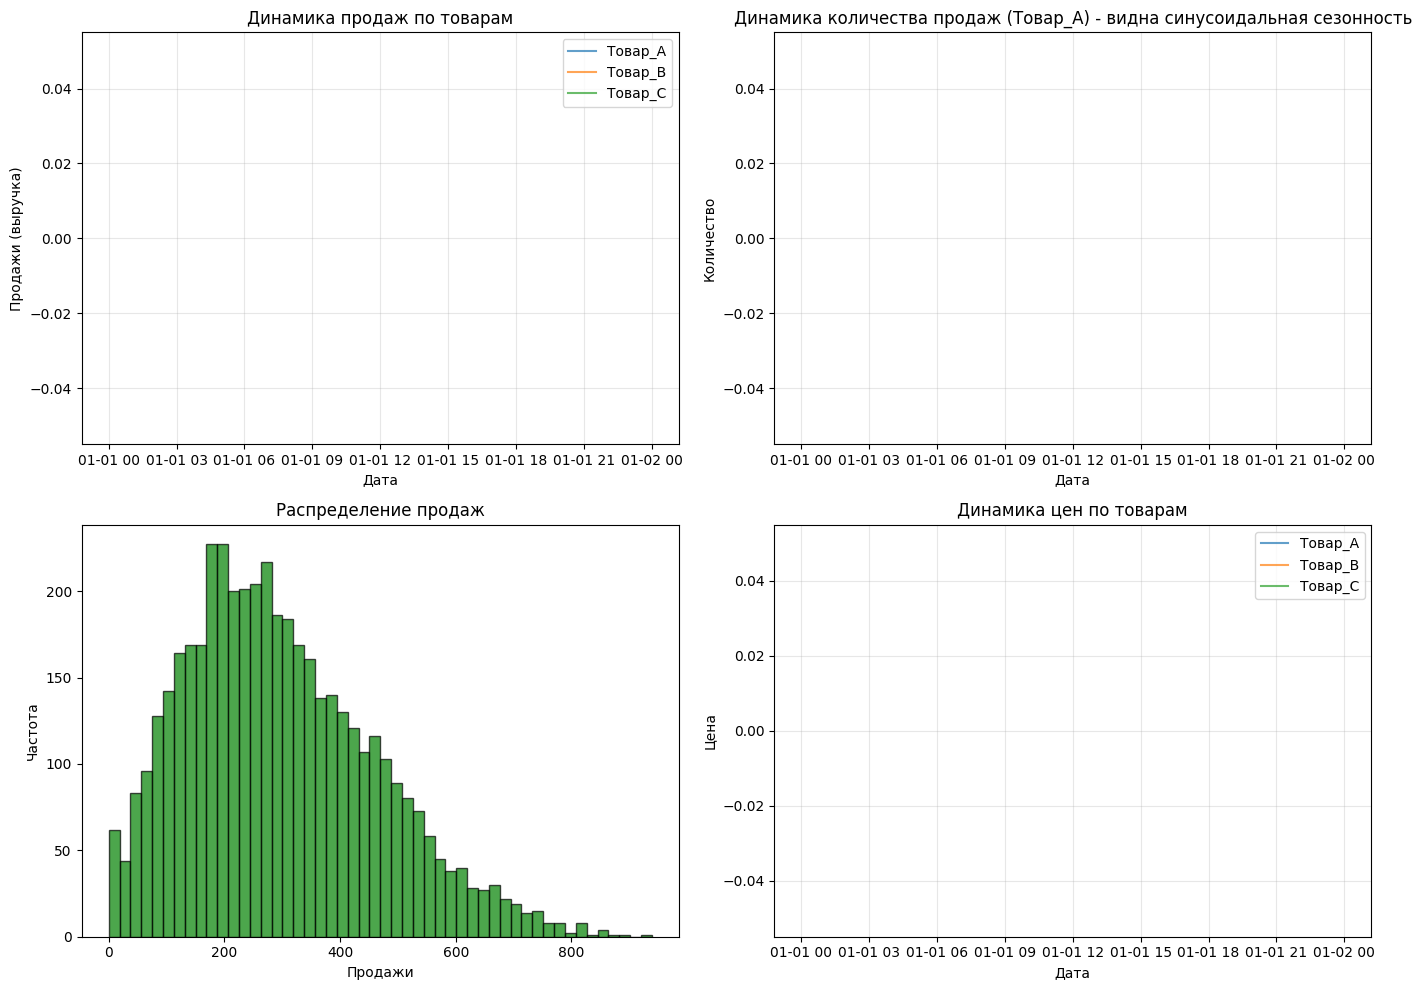

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # ============================================
# # Генерация датасета с синусоидальной сезонностью
# # ============================================

# np.random.seed(42)

# # Параметры
# n_days = 500  # количество дней
# seasonal_period = 30  # период сезонности (30 дней)
# amplitude = 100  # амплитуда сезонности
# trend = 0.5  # линейный тренд
# noise_std = 15  # стандартное отклонение шума

# # Создаем даты
# dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

# # Товары
# products = ['Товар_A', 'Товар_B', 'Товар_C']
# product_prices = {'Товар_A': 100, 'Товар_B': 150, 'Товар_C': 200}

# # Базовое количество для каждого товара
# base_quantity = {'Товар_A': 200, 'Товар_B': 150, 'Товар_C': 100}

# # Создаем DataFrame
# data = []

# for product in products:
#     for i, date in enumerate(dates):
#         # Синусоидальная сезонность
#         seasonal = amplitude * np.sin(2 * np.pi * i / seasonal_period)
        
#         # Линейный тренд
#         trend_component = trend * i
        
#         # Случайный шум
#         noise = np.random.normal(0, noise_std)
        
#         # Количество продаж
#         quantity = base_quantity[product] + seasonal + trend_component + noise
#         quantity = max(0, int(quantity))  # количество не может быть отрицательным
        
#         # Цена с небольшой сезонностью и шумом
#         price = product_prices[product] + 5 * np.sin(2 * np.pi * i / seasonal_period) + np.random.normal(0, 2)
#         price = max(price, product_prices[product] * 0.8)  # минимальная цена -20% от базовой
        
#         # Выручка
#         sales = price * quantity
        
#         data.append({
#             'date': date,
#             'product': product,
#             'price': round(price, 2),
#             'quantity': quantity,
#             'sales': round(sales, 2)
#         })

# df = pd.DataFrame(data)

df = pd.read_csv('sales_data.csv', parse_dates=['date'])
display(df)
print(f"\nРазмер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"\nСтатистика по продажам:")
print(df['sales'].describe())

# ============================================
# Визуализация
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Динамика продаж по товарам
for product in products:
    product_df = df[df['product'] == product]
    axes[0, 0].plot(product_df['date'], product_df['sales'], label=product, alpha=0.7)
axes[0, 0].set_title('Динамика продаж по товарам')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Продажи (выручка)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Количество продаж для Товар_A (видна сезонность)
product_a = df[df['product'] == 'Товар_A']
axes[0, 1].plot(product_a['date'], product_a['quantity'], 'b-', alpha=0.7, linewidth=1)
axes[0, 1].set_title('Динамика количества продаж (Товар_A) - видна синусоидальная сезонность')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение продаж (гистограмма)
axes[1, 0].hist(df['sales'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Распределение продаж')
axes[1, 0].set_xlabel('Продажи')
axes[1, 0].set_ylabel('Частота')

# 4. Динамика цен по товарам
for product in products:
    product_df = df[df['product'] == product]
    axes[1, 1].plot(product_df['date'], product_df['price'], label=product, alpha=0.7)
axes[1, 1].set_title('Динамика цен по товарам')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Цена')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.to_csv('sales_data.csv', index=False, encoding='utf-8')

ПРЕДОБРАБОТКА ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ 

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('sales_data.csv', parse_dates=['date'])

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print("Размер выборок:")
print(f"  train: {len(train)} записей")
print(f"  test:  {len(test)} записей")


def preprocess_for_lr(df, is_train=True):
    df = df.copy()
    
    # Извлекаем признаки из даты
    df['day_of_week'] = df['date'].dt.dayofweek      # день недели (0=пн, 6=вс)
    df['month'] = df['date'].dt.month                # месяц (1-12)
    df['day_of_year'] = df['date'].dt.dayofyear      # день в году (1-365)
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)  # выходной ли день (1=да, 0=нет)
    
    # One-hot кодирование
    df = pd.get_dummies(df, columns=['product'], prefix='product', drop_first=False)
    
    # Убедимся, что колонки с товарами есть (на случай если в test нет какого-то товара)
    product_cols = ['product_product_0', 'product_product_1', 'product_product_2']
    for col in product_cols:
        if col not in df.columns:
            df[col] = 0
    
    return df

train_processed = preprocess_for_lr(train, is_train=True)
test_processed = preprocess_for_lr(test, is_train=False)

# Числовые признаки
numeric_features = ['price', 'sales', 'day_of_week', 'month', 'day_of_year', 'weekend']

# Категориальные признаки (one-hot)
product_features = ['product_product_0', 'product_product_1', 'product_product_2']

# Все признаки
all_features = numeric_features + product_features

# Целевая переменная
target = 'quantity'

# Разделение на выборки
X_train = train_processed[all_features]
y_train = train_processed[target]
X_test = test_processed[all_features]
y_test = test_processed[target]

print(f"\nФорма данных:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

# Проверка на пропуски + заполнение средним значением если есть
for col in numeric_features:
    if test_processed[col].isnull().sum() > 0:
        median_val = train_processed[col].median()
        test_processed[col] = test_processed[col].fillna(median_val)

display(train_processed[['date', 'sales'] + all_features])

# Масштабирование
scaler = StandardScaler()
# scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_features)

print("\nПосле масштабирования:")
display(X_train_scaled_df.head())

Размер выборок:
  train: 3600 записей
  test:  900 записей

Форма данных:
  X_train: (3600, 9)
  X_test:  (900, 9)


,date,sales,price,sales,day_of_week,month,day_of_year,weekend,product_product_0,product_product_1,product_product_2
0,2026-01-01,144.176308,13.703246,144.176308,3,1,1,0,True,False,False
1,2026-01-02,136.367007,10.070948,136.367007,4,1,2,0,True,False,False
2,2026-01-03,213.956185,13.962327,213.956185,5,1,3,1,True,False,False
3,2026-01-04,131.345925,9.099661,131.345925,6,1,4,1,True,False,False
4,2026-01-05,106.939243,7.994872,106.939243,0,1,5,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3595,2027-08-19,172.275752,10.726114,172.275752,3,8,231,0,False,False,True
3596,2027-08-20,274.247971,13.713747,274.247971,4,8,232,0,False,False,True
3597,2027-08-21,80.407377,5.509914,80.407377,5,8,233,1,False,False,True
3598,2027-08-22,230.777833,8.823299,230.777833,6,8,234,1,False,False,True



После масштабирования:


,price,sales,day_of_week,month,day_of_year,weekend,product_product_0,product_product_1,product_product_2
0,1.296454,-0.822312,-0.000695,-1.519357,-1.643942,-0.632210,1.183216,-0.845154,-0.447214
1,0.028392,-0.870268,0.499496,-1.519357,-1.634511,-0.632210,1.183216,-0.845154,-0.447214
2,1.386901,-0.393802,0.999688,-1.519357,-1.625081,1.581754,1.183216,-0.845154,-0.447214
3,-0.310692,-0.901102,1.499879,-1.519357,-1.615651,1.581754,1.183216,-0.845154,-0.447214
4,-0.696382,-1.050981,-1.501268,-1.519357,-1.606221,-0.632210,1.183216,-0.845154,-0.447214


МОДЕЛЬКА
1. ЛИНЕЙНАЯ РЕГРЕССИЯ - BASELINE

In [30]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error

print("Linear Regression")

lr = LinearRegression()
lr.fit(X_train_scaled_df, y_train)

y_train_pred_lr = lr.predict(X_train_scaled_df)
y_test_pred_lr = lr.predict(X_test_scaled_df)

r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)
mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print(f"    R² на обучающей выборке: {r2_train_lr:.4f}")
print(f"    R² на тестовой выборке:  {r2_test_lr:.4f}")
print(f"    MAE на тестовой выборке: {mae_lr:.2f}")

Linear Regression
    R² на обучающей выборке: 0.9266
    R² на тестовой выборке:  0.8246
    MAE на тестовой выборке: 3.06


LSTM

После аугментации: 1485 последовательностей

Форма данных:
  X_train: (1113, 15, 1)
  X_test:  (372, 15, 1)

Начинаем обучение...
Epoch 20/150 - Train Loss: 0.004089 - Val Loss: 0.004148
Epoch 40/150 - Train Loss: 0.003823 - Val Loss: 0.004888
Epoch 60/150 - Train Loss: 0.003784 - Val Loss: 0.006349
Epoch 80/150 - Train Loss: 0.003794 - Val Loss: 0.004542
Epoch 100/150 - Train Loss: 0.003583 - Val Loss: 0.003737
Epoch 120/150 - Train Loss: 0.003610 - Val Loss: 0.003674
Epoch 140/150 - Train Loss: 0.003569 - Val Loss: 0.005924

РЕЗУЛЬТАТЫ LSTM (улучшенная версия):
  R² на обучении: 0.8997
  R² на тесте:    0.7745
  MAE на обучении: 2.92
  MAE на тесте:    3.27


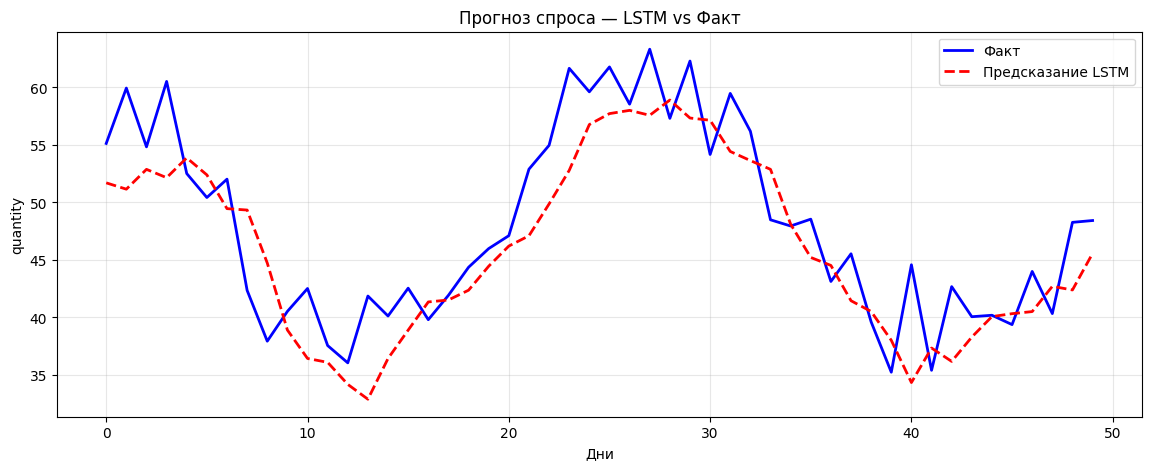

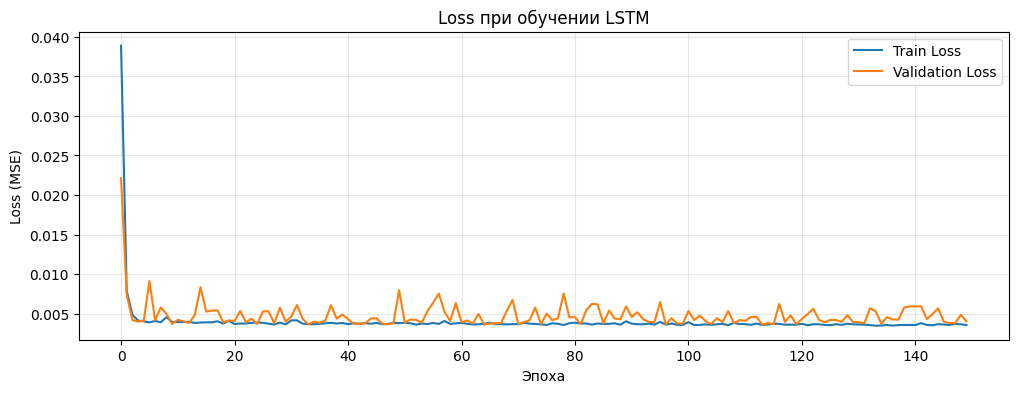

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Загружаем данные
df = pd.read_csv('sales_data.csv', parse_dates=['date'])

# Берём один товар
df = df[df['product'] == 'product_0'].copy()
df = df.sort_values('date').reset_index(drop=True)

target_col = 'quantity'

# УВЕЛИЧИВАЕМ ДАННЫЕ
def create_sequences_augmented(data, seq_length=20, step=1):
    X, y = [], []
    for i in range(0, len(data) - seq_length, step):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Масштабируем
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[[target_col]])

# Меньше seq_length, но больше данных
seq_length = 15  # смотрим 15 дней вместо 30
step = 1

X, y = create_sequences_augmented(scaled_data, seq_length, step)

print(f"После аугментации: {len(X)} последовательностей")

# Разделяем (75/25)
split = int(len(X) * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Конвертируем в тензоры
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# DataLoader
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"\nФорма данных:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

#  МОДЕЛЬ
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        return out

# ОБУЧЕНИЕ С ЛУЧШИМИ ПАРАМЕТРАМИ
model = SimpleLSTM(input_size=1, hidden_size=32, num_layers=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 150
train_losses = []
val_losses = []


for epoch in range(epochs):
    # Train
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_loss = criterion(val_pred, y_test_tensor).item()
        val_losses.append(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f} - Val Loss: {val_loss:.6f}")

# Оценка
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).numpy()
    y_test_pred = model(X_test_tensor).numpy()

# Обратное масштабирование
y_train_actual = scaler.inverse_transform(y_train)
y_train_pred_actual = scaler.inverse_transform(y_train_pred)
y_test_actual = scaler.inverse_transform(y_test)
y_test_pred_actual = scaler.inverse_transform(y_test_pred)

# Метрики
mae_train = mean_absolute_error(y_train_actual, y_train_pred_actual)
mae_test = mean_absolute_error(y_test_actual, y_test_pred_actual)
r2_train = r2_score(y_train_actual, y_train_pred_actual)
r2_test = r2_score(y_test_actual, y_test_pred_actual)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ LSTM (улучшенная версия):")
print(f"  R² на обучении: {r2_train:.4f}")
print(f"  R² на тесте:    {r2_test:.4f}")
print(f"  MAE на обучении: {mae_train:.2f}")
print(f"  MAE на тесте:    {mae_test:.2f}")
print("="*50)

# График предсказаний
plt.figure(figsize=(14, 5))
n_display = min(50, len(y_test_actual))
plt.plot(y_test_actual[-n_display:], label='Факт', color='blue', linewidth=2)
plt.plot(y_test_pred_actual[-n_display:], label='Предсказание LSTM', color='red', linestyle='--', linewidth=2)
plt.title('Прогноз спроса — LSTM vs Факт')
plt.xlabel('Дни')
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# График обучения
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss при обучении LSTM')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()